### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import sklearn.metrics as metrics
from sklearn import neighbors 
import sklearn

In [2]:
#font = {'size'   : 20}
#matplotlib.rc('font', **font)
#matplotlib.rc('xtick', labelsize=20) 
#matplotlib.rc('ytick', labelsize=20) 
#matplotlib.rcParams['figure.dpi'] = 300

In [3]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión
from sklearn import tree
from sklearn.tree import export_graphviz 

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [4]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [5]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [6]:
LearningSet.info()
print("Rows:", LearningSet.shape[0], "Columns:", LearningSet.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_NAME       18 non-null     object 
 1   S_MASS       18 non-null     float64
 2   P_PERIOD     18 non-null     float64
 3   P_DISTANCE   18 non-null     float64
 4   P_HABITABLE  18 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 864.0+ bytes
Rows: 18 Columns: 5


In [7]:
print("P_HABITABLE corresponde a la categoría:", LearningSet["P_HABITABLE"].dtype)

P_HABITABLE corresponde a la categoría: int64


In [8]:
LearningSet #visualizamos el learning set y sus respectivos ejemplos

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [9]:
#asignamos variables para la masa, periodo y habitabilidad
masa = LearningSet["S_MASS"]
periodo = LearningSet["P_PERIOD"]
habitable = LearningSet["P_HABITABLE"] == True

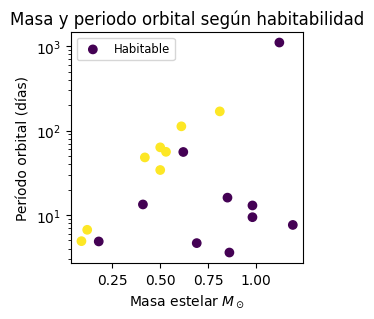

In [10]:
#ploteo
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(masa, periodo, c=habitable, label = "Habitable")


ax.set_title("Masa y periodo orbital según habitabilidad")
ax.set_xlabel("Masa estelar $M_\odot$")
ax.set_ylabel("Período orbital (días)")


ax.set_yscale("log") #escala log

ax.legend(scatterpoints=1, markerscale=1, fontsize="small")

plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


- **Se separan de forma relativamente fácil; podemos ver una suerte de linea que separa los planetas no habitables de los que son habitables, agrupados al lado inferior derecho del gráfico.**

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [11]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [12]:
TrainSet =  LearningSet.iloc[:13,:]  

TestSet = LearningSet.iloc[13:,:]

In [13]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [14]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [15]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [16]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [17]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [18]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [19]:
ytrain

0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64

### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [20]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión

In [21]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

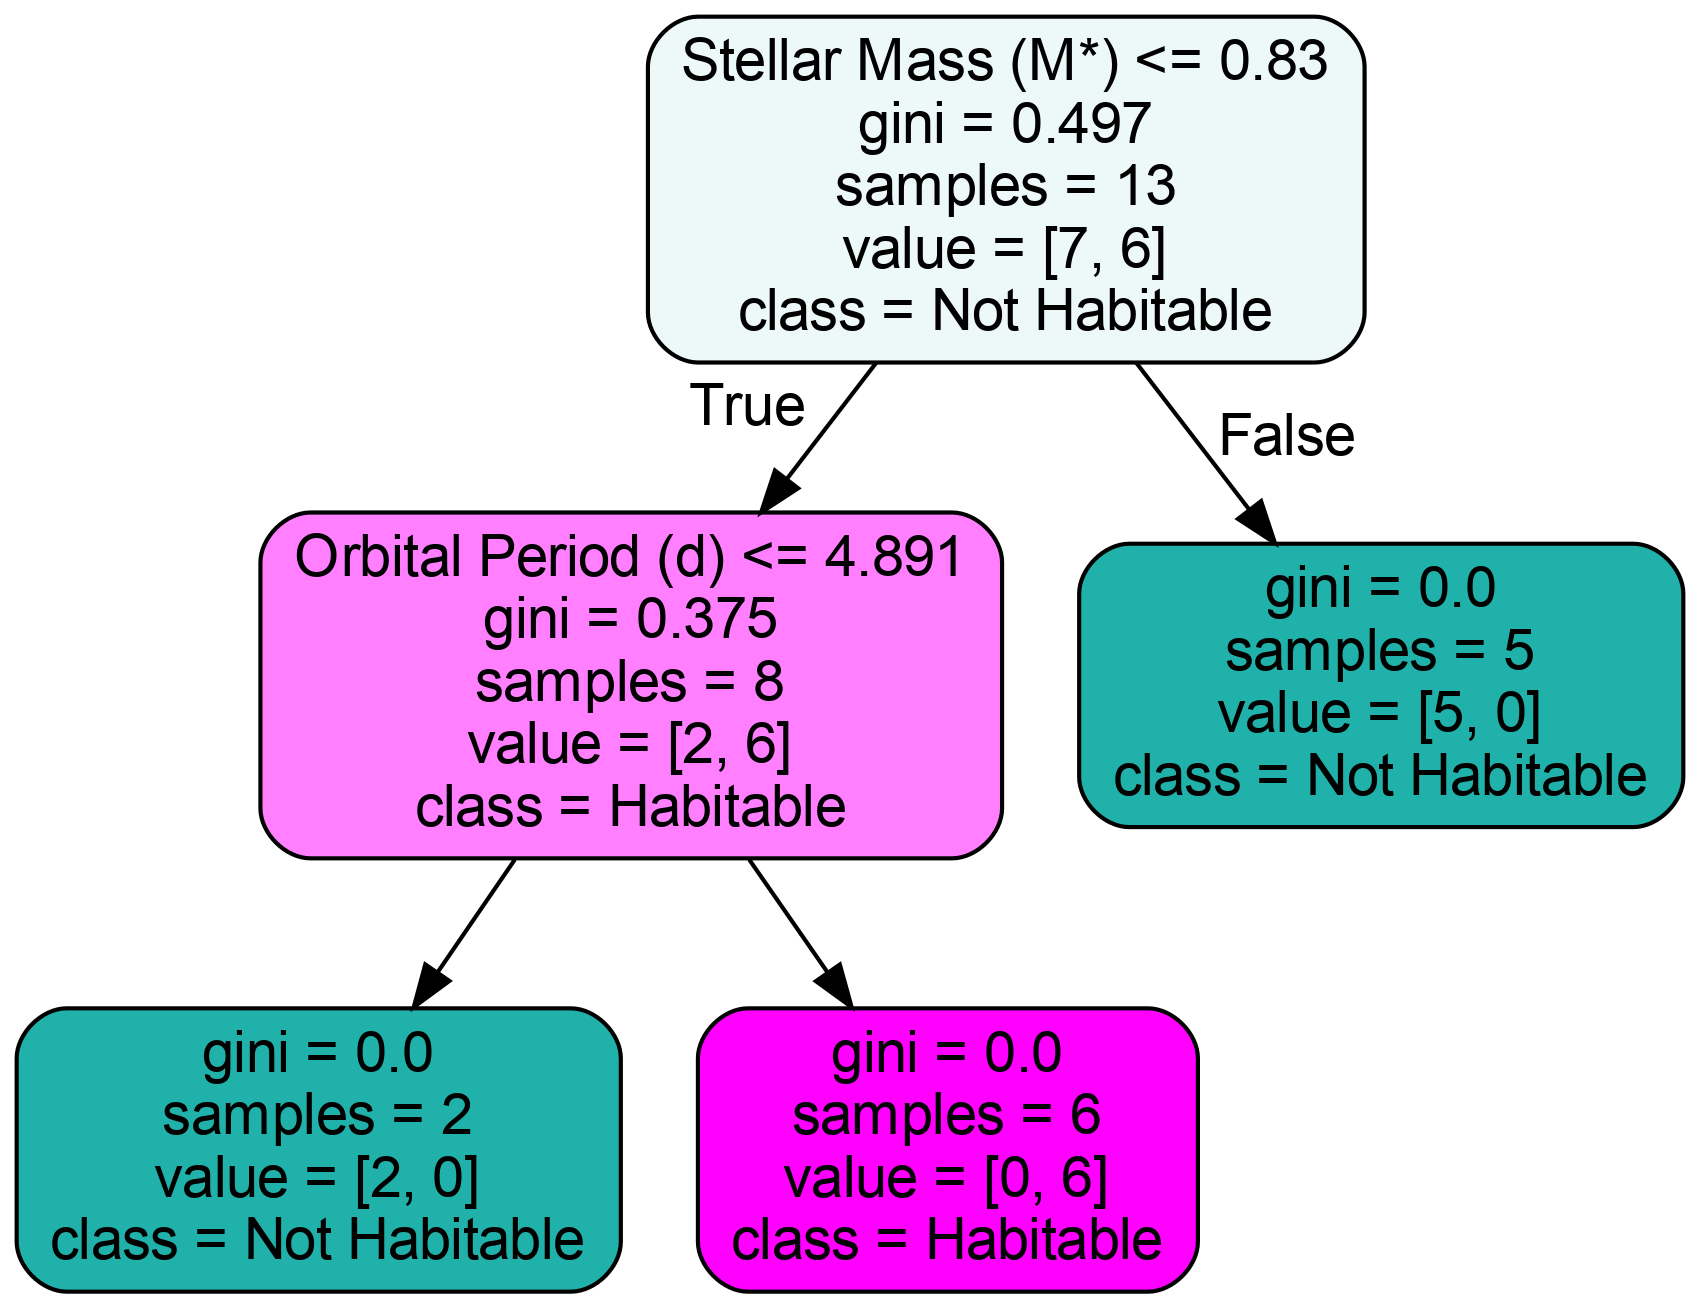

In [22]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

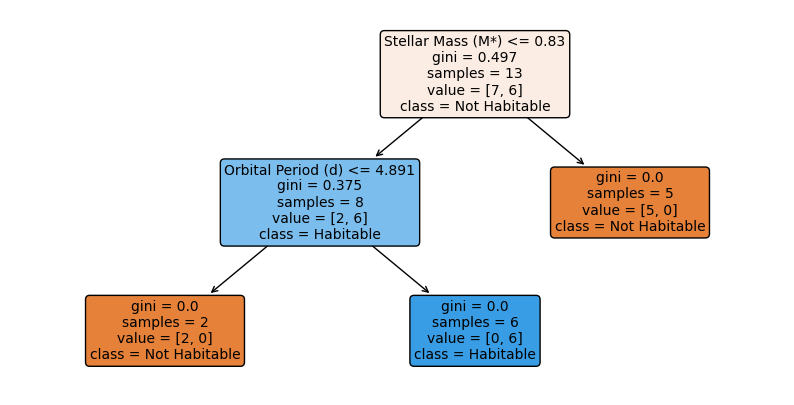

In [23]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

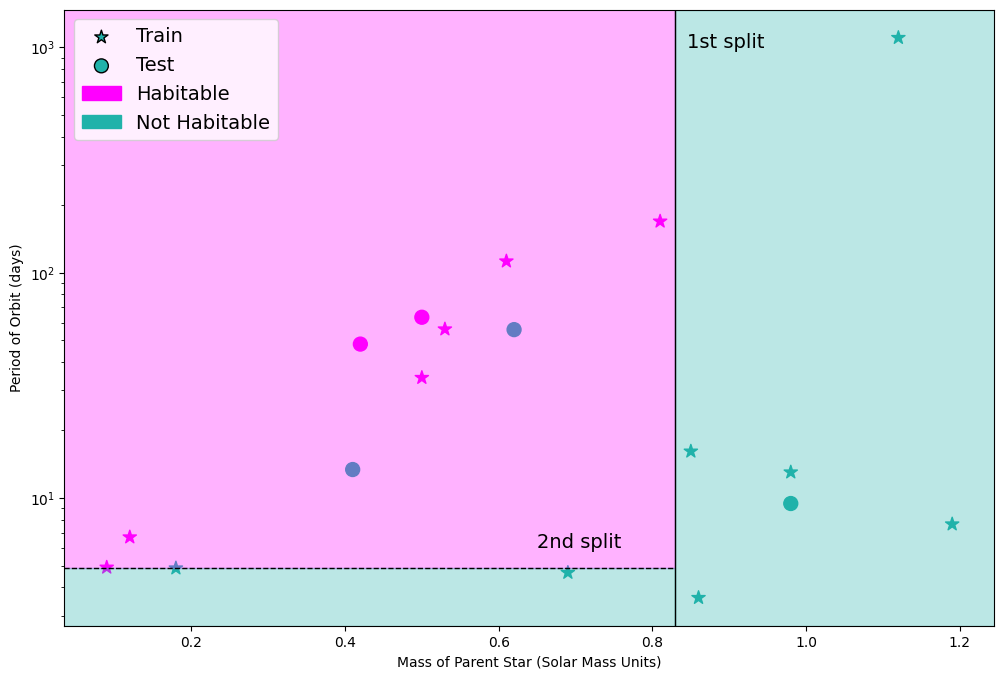

In [24]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?

- **En el set de entrenamiento, todas las estrellas pertenecen al split adecuado según su clasificación. En cuanto al set de prueba, vemos que hay 2 círculos azules en la zona de habitabilidad: 2/5 de las clasificaciones correctas.**


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [25]:
import sklearn.metrics as metrics

In [26]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [27]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [28]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [29]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
- **Vemos que el conjunto de entrenamiento recibe un 1.0 en accuracy o 100%; en principio el árbol clasifica perfectamente el conjunto.**
2. ¿Qué ocurre en el conjunto de prueba?
- **En el conjunto de prueba obtenemos un accuracy de 0.6 o 60%, podemos pensar que los datos de entrenamiento se adecuaron de forma incorrecta.**
3. ¿Qué variable aparece en la raíz del árbol?
- **En la raíz del árbol observamos que la variable es Masa Estelar como primer desglose.**
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?
- **Parece un árbol acorde en complejidad dado el tamaño del dataset. Teniendo más datos de entrenamiento, podemos esperar que el árbol se extienda en profundidad.**

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [30]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`)
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [31]:
TrainSet2 #visualizamos

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1
10,Kepler-296 e,0.50,34.142110,0.178202,1
11,Kepler-705 b,0.53,56.056054,0.231926,1
12,Kepler-445 c,0.18,4.871229,0.031746,0
13,HD 104067 b,0.62,55.806000,0.260000,0
14,GJ 4276 b,0.41,13.352000,0.087613,0


In [32]:
TestSet2 #visualizamos

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0


In [33]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento 2

Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento 2

In [34]:
Xtrain2.columns #visualizamos columnas

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [35]:
ytrain2 = TrainSet2.P_HABITABLE #target conjunto prueba 2

ytest2 = TestSet2.P_HABITABLE  #target conjunto prueba 2

In [36]:
ytrain2 #visualizamos

5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
13    0
14    0
15    1
16    0
17    1
Name: P_HABITABLE, dtype: int64

In [37]:
ytest2 #visualizamos

0    0
1    0
2    0
3    1
4    0
Name: P_HABITABLE, dtype: int64

In [38]:
model2 = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo 2 con sus parámetros

model2.fit(Xtrain2, ytrain2) #En una línea, construimos el modelo 2

DecisionTreeClassifier(random_state=3)

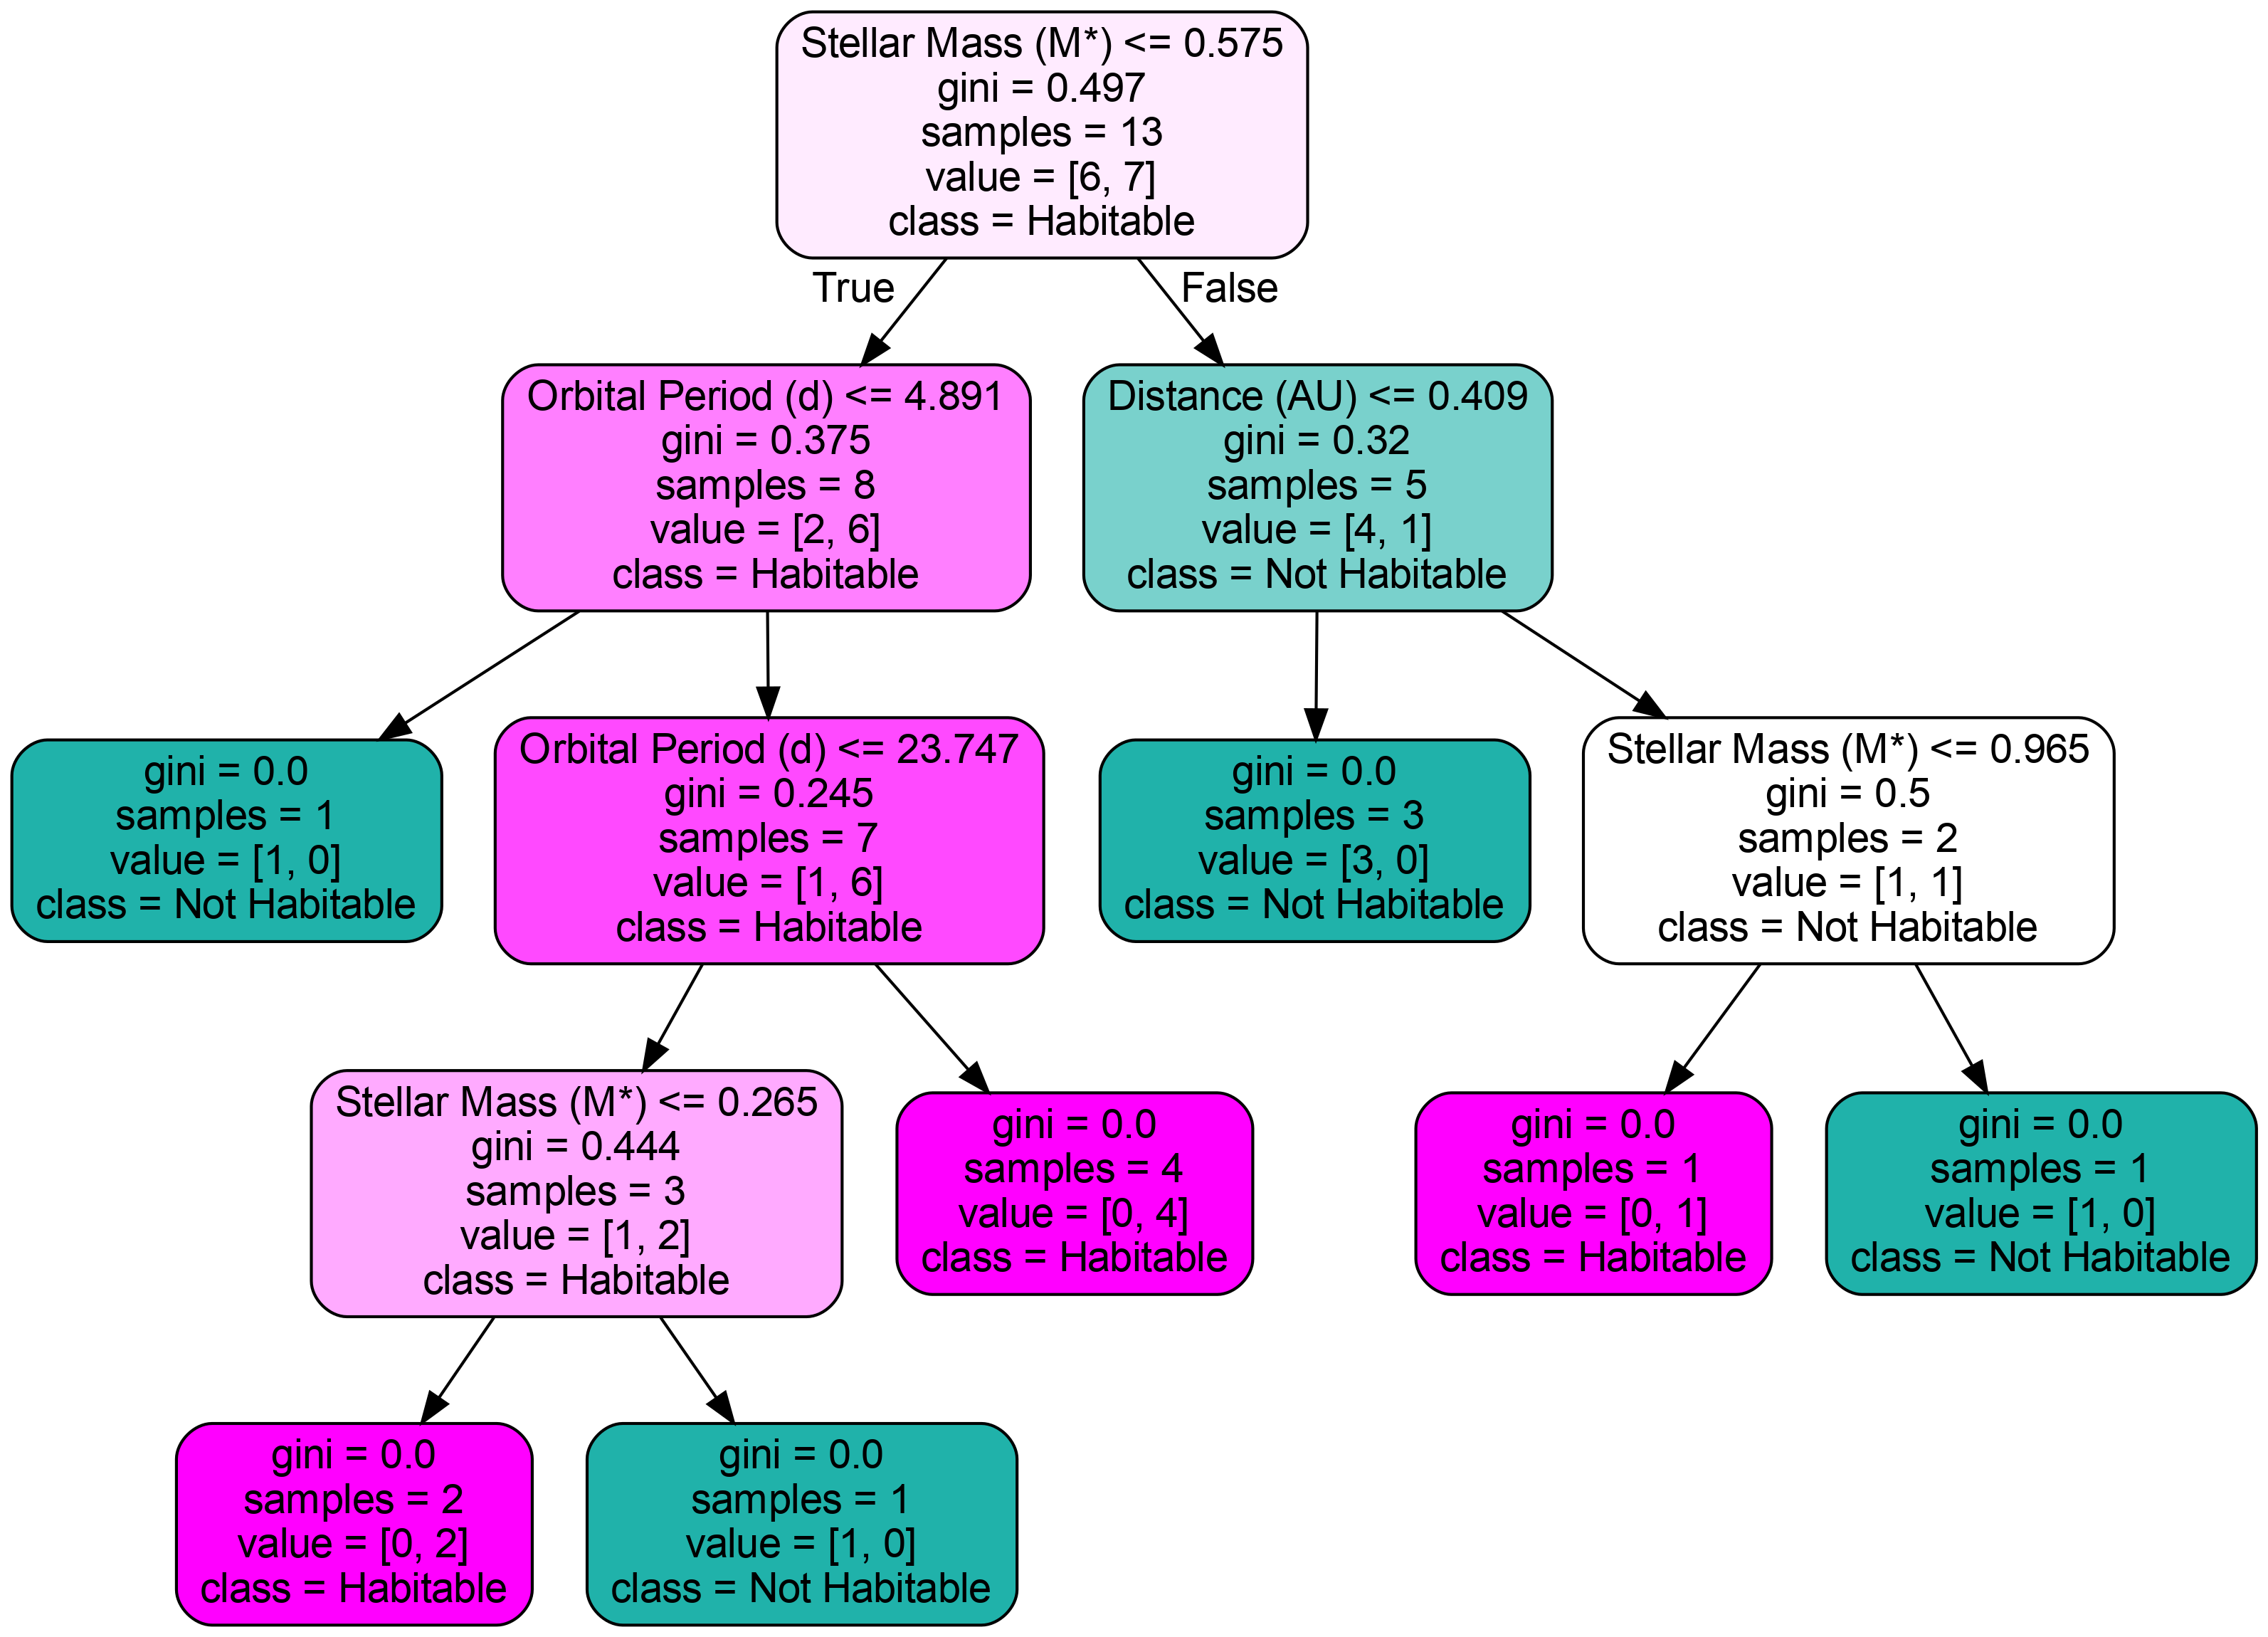

In [39]:
dot_data = StringIO()
export_graphviz(
            model2,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

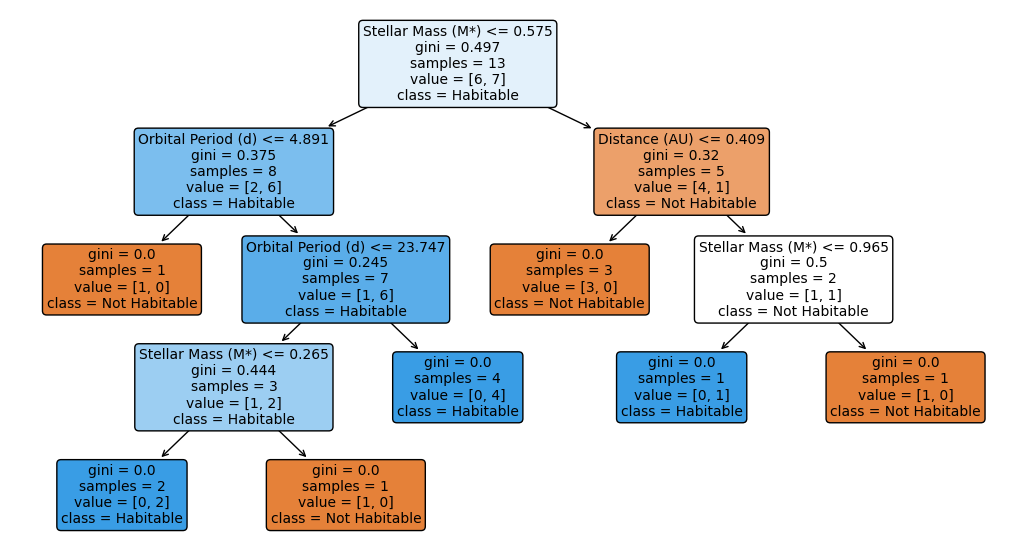

In [40]:
plt.figure(figsize=(13,7))  #cambiamos a (13, 7)
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

In [41]:
ypred2 = model2.predict(Xtest2) #generamos etiquetas de predicción en el set de prueba 2

In [42]:
ypred2 #visualizamos

array([0, 0, 0, 1, 0])

In [43]:
metrics.accuracy_score(ytest2, ypred2) #test score 2

1.0

In [44]:
metrics.accuracy_score(ytrain2, model2.predict(Xtrain2)) #train score 2

1.0

### Preguntas:

1. Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

- **Notamos una gran diferencia: el inicial tenía tan solo 3 splits, mientras que el obtenido ahora presenta una mayor complejidad por su cantidad de niveles.**

2. ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? 

- **Obtenemos un accuracy de 1.0 o 100%: todas las clasificaciones fueron correctas.**

3. ¿Y en el conjunto de prueba?

- **En el conjunto de prueba también obtenemos de 1.0 o 100%: todas fueron correctas.**

4. Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?

- **En principio, este árbol parece ser mejor. Pero hay que tener cuidado. Podría existir algún tipo de inconsistencia o bias en los datos que revisar. Además, con tan pocos datos, es difícil saber si el modelo es realmente útil.**

### Conclusiones

- Que puede concluir respecto al ejercicio?

- Cambian los resultados dependiendo del set de datos que utilizamos?

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

- **Concluimos que las elecciones tanto del set de prueba como del de entrenamiento resultan cruciales en cuanto a los resultados que se obtienen eventualmente. La Tierra debería en principio ser catalogada como habitable dado el accuracy del 100% en el set de entrenamiento y prueba.**

## k-Nearest Neighbors 

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [45]:
from sklearn import neighbors 
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [46]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [47]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [48]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [49]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [50]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [51]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [52]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2])))
#Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [53]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

Usamos la distancia del tercer vecino como el radio del círculo que encierra vecinos

In [54]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    
    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

/tmp/ipykernel_7372/2436615752.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
/tmp/ipykernel_7372/2436615752.py:11: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\


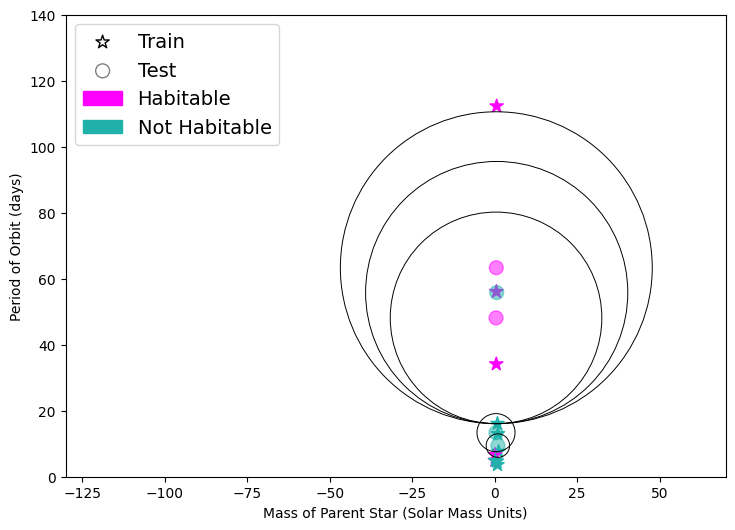

In [55]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

**Notamos un inconveniente en la escala de los datos; vemos que se acumulan los circulos y estrellas en la zona inferior, de forma que no podemos visualizar correctamente los resultados de habitabilidad.**

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [56]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [57]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [58]:
scaledXTrain = scaler.transform(Xtrain)

In [59]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [60]:
scaledXtest = scaler.transform(Xtest) 

In [61]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [62]:
#scaledXTrain, scaledXtest

In [63]:
model_s = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [64]:
model_s

KNeighborsClassifier(n_neighbors=3)

In [65]:
scaledXTrain = pd.DataFrame(scaledXTrain, columns=Xtrain.columns) #pasamos a DataFrame para trabajar con facilidad
scaledXtest = pd.DataFrame(scaledXtest, columns=Xtest.columns)

In [66]:
scaledXTrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.472222,-0.183604
1,0.444444,0.060388
2,1.388889,-0.104673
3,-0.222222,1.941757
4,0.805556,0.000000
5,-1.666667,-0.158019
6,0.000000,-0.162997
7,-1.583333,-0.123237
8,1.194444,21.311672
9,0.333333,3.046552


In [67]:
model_s.fit(scaledXTrain.iloc[:,:2],ytrain) 
#esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred_2 = model_s.predict(scaledXtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [68]:
ytestpred_2, ytest.values #comparación

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [69]:
print(metrics.accuracy_score(ytrain, model_s.predict(scaledXTrain.iloc[:,:2])))
#Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model_s.predict(scaledXtest.iloc[:,:2])))
#mismo que anterior, pero para set de prueba

0.8461538461538461
0.8


In [70]:
model_s.kneighbors(scaledXtest.iloc[:,:2])
#el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[0.2500478 , 0.53900086, 1.00570768],
        [0.47721081, 0.66005572, 0.79614695],
        [0.16494121, 0.57079985, 1.00501058],
        [0.06956397, 0.35230123, 0.38378203],
        [0.34256727, 0.35245873, 1.07701084]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  0,  1],
        [11, 10, 12]]))

In [71]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    
    print(model_s.kneighbors(scaledXtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

1.0057076822074733
0.7961469534072081
1.0050105812138872
0.3837820313273946
1.0770108415685602


/tmp/ipykernel_7372/1392387193.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(scaledXTrain['S_MASS'], scaledXTrain['P_PERIOD'], marker = '*',facecolor = 'None',\
/tmp/ipykernel_7372/1392387193.py:11: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(scaledXtest['S_MASS'], scaledXtest['P_PERIOD'], marker = 'o',facecolor = 'None',\


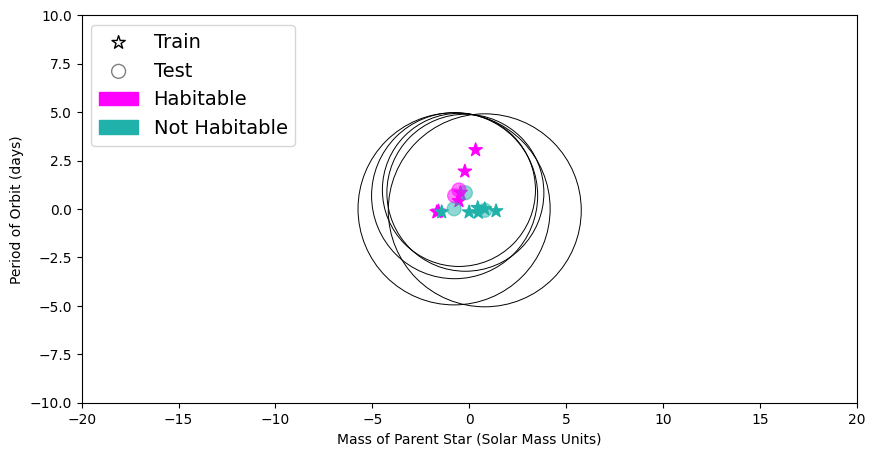

In [72]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(scaledXTrain['S_MASS'], scaledXTrain['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(scaledXtest['S_MASS'], scaledXtest['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(scaledXtest)): #plot neighbors

    circle1=plt.Circle((scaledXtest['S_MASS'].iloc[i],scaledXtest['P_PERIOD'].iloc[i]),model.kneighbors(scaledXtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-20,20)
plt.ylim(-10,10)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Preguntas 

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

- **No tiene el mismo problema.**

- Compare las fortalezas y debilidades de DT y kNN

- **Entre las principales fortalezas y debilidades: DT no requiere escalado de datos y kNN sí; DT permite ver el razonamiento lógico, no tanto con kNN; kNN apenas requiere procesamiento previo; DT puede cambiar bastante con pequeñas alteraciones en los datos.**

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

- **Los árboles de decisión se basan en decisiones lógicas de elección según ciertos valores, no en "espaciados" como el kNN.**

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

- **Debemos corroborar si el modelo fue entrenado correctamente de forma transversal. Es posible que con los datos de entrenamiento se llegue a un valor perfecto, pero al momento de predecir datos externos el modelo se quede corto, donde podríamos obtener accuracy bajos. Es necesario comprobar.**

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

- **kNN se basa en las distancias que existen entre los datos, los árboles de decisión trabajan con decisiones lógicas que no necesariamente tienen que ver con naturaleza espacial de algún tipo.**

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

- **Ambos resultan bastante buenos, pero elegiría árbol de decisión. Con un dataset mucho más grande, es posible que el árbol se vuelva demasiado complejo y kNN sea útil para una visualización más cómoda.**
